# Hyperparameter Sweep Analysis

The goal of this notebook is to analyze the hyperparameter configurations identified by the sweep for our current training pipeline, which includes:

- **Blurred backgrounds** (see [Background Interventions Notebook](01_background_interventions.ipynb))
- **DINOv3** backbone (see [Backbone Notebook](02_backbone.ipynb))
- Combined **ProxyAnchor + Center Loss** (see [Loss Combined Notebook](04_loss_combined.ipynb))
- **Adam** optimizer (see [Optimizer Notebook](05_optimizers.ipynb))
- **CosineAnnealingLR** scheduler (see [Scheduler Notebook](06_scheduler.ipynb))
- Class balancing via a weighted sampler (see [Class Balance Notebook](07_class_balance.ipynb))

The hyperparameter sweep was conducted using the **wandb API**, with the objective of maximizing `final_val_mAP` at the end of each training run.

In this notebook, we evaluate the top three configurations across multiple seeds to validate their performance and robustness.


## 1. Setup and Configuration

This section defines the required imports and configuration settings used throughout the notebook. These include library dependencies and any global parameters.

In [ ]:
EXPERIMENT_NAME = "08b_hyperparameter_sweep"
RANDOM_SEED = 66

# -----------------------------
# Environment setup
# -----------------------------
import os
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

# -----------------------------
# Standard library imports
# -----------------------------
from dotenv import load_dotenv
from pathlib import Path
import sys
import time

# -----------------------------
# Third-party libraries
# -----------------------------
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tabulate import tabulate
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import wandb

import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

# -----------------------------
# Project path setup
# -----------------------------
PROJECT_PATH = Path.cwd().parent
sys.path.insert(0, str(PROJECT_PATH))

# -----------------------------
# Local modules
# -----------------------------
from src.criterions import (
    CenterLoss,
    CombinedLoss,
    ProxyAnchorLoss,
)
from src.datasets import BlurImageDataset, EmbeddingDataset
from src.models import EmbeddingProjection
from src.training import train_loop
from src.utils import (
    create_deterministic_training_dataloader,
    get_device,
    set_seeds,
    extract_embeddings, get_embeddings,
)
from src.visualization import (
    plot_history,
    visualize_embeddings_mds,
    visualize_nearest_neighbors,
)

# -----------------------------
# Reproducibility
# -----------------------------
set_seeds(RANDOM_SEED)
print(f"PyTorch version: {torch.__version__}")

Define shared paths for the whole project.

In [2]:
# Define paths
DATA_PATH = PROJECT_PATH / "data"
OUTPUT_PATH = PROJECT_PATH / "output" / EXPERIMENT_NAME
OUTPUT_PATH_SHARED = PROJECT_PATH / "output" / "shared"
CHECKPOINT_PATH = PROJECT_PATH / "checkpoints" / EXPERIMENT_NAME
EMBEDDINGS_PATH = CHECKPOINT_PATH / "embeddings"

DATA_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH_SHARED.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_PATH.mkdir(parents=True, exist_ok=True)

# Load environment variables from .env file
load_dotenv(dotenv_path=PROJECT_PATH / ".env")

True

In [ ]:
# Configuration
shared_config = {
    # W&B Sweep ID for analysis
    "sweep_id": "", # TODO: Add your sweep ID here after creating the sweep in W&B
    "num_top_runs": 3,  # Number of top runs to analyze from the sweep

    # Dinov3 Model
    "dinov3_model": "hf-hub:timm/vit_base_patch16_dinov3.lvd1689m",

    # Training
    "num_epochs": 200,
    "patience": 10,
    "val_split": 0.2,
    
    # Reproducibility
    "seed": RANDOM_SEED,
}

print("Shared Configuration:")
for key, value in shared_config.items():
    print(f"  {key}: {value}")

In [ ]:
# Initialize Weights and Biases for experiment tracking
# Key hyperparameters are tracked explicitly for easy filtering in W&B dashboard
if not os.getenv("WANDB_API_KEY"):
    print("Warning: WANDB_API_KEY not found in environment variables. W&B logging will be disabled.")
else:
    wandb.login()

    wandb.init(
        project=os.getenv("WANDB_PROJECT", "jaguar-reid-karl-matti-schuetz"),
        name=EXPERIMENT_NAME,
    )

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: karl-schuetz (karl-schuetz-hasso-plattner-institut) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Data Loading

In [5]:
# Load training data
train_df = pd.read_csv(DATA_PATH / "train.csv").set_index("filename")

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

Training dataset:
  Total images: 1895
  Unique identities: 31

Sample rows:
               ground_truth
filename                   
train_0001.png        Abril
train_0002.png        Abril
train_0003.png        Abril
train_0004.png       Akaloi
train_0005.png       Akaloi


Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)

Identity coverage:
  Identities in training:   31
  Identities in validation: 31
  Overlap: 31
  All identities present in both sets


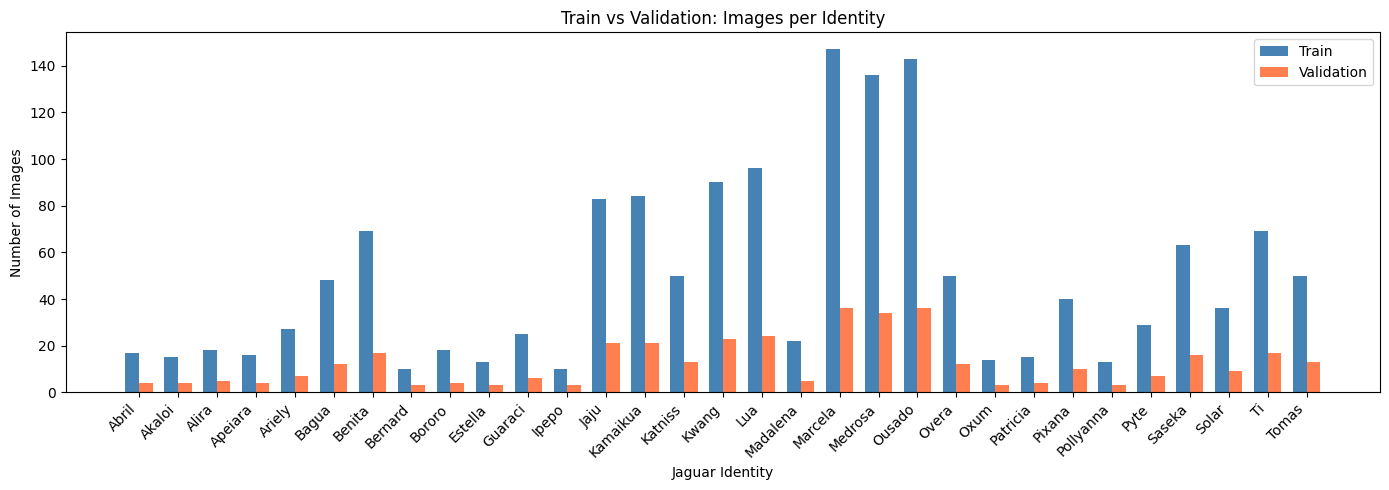


Logged identity distributions to W&B
  Train samples per identity: 10 - 147 (mean: 48.9)
  Val samples per identity: 3 - 36 (mean: 12.2)


In [ ]:
# Create stratified train/validation split
# This ensures all identities appear in both sets

# Encode labels to integers
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

# Stratified split: each identity's images are split proportionally
train_data, val_data = train_test_split(
    train_df,
    test_size=shared_config["val_split"],
    random_state=shared_config["seed"],
    stratify=train_df['ground_truth']  # Ensures proportional representation
)

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-shared_config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*shared_config['val_split']:.0f}%)")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())

print(f"\nIdentity coverage:")
print(f"  Identities in training:   {len(train_identities)}")
print(f"  Identities in validation: {len(val_identities)}")
print(f"  Overlap: {len(train_identities & val_identities)}")

if train_identities == val_identities:
    print("  All identities present in both sets")

# Log identity distributions to W&B
train_counts = train_data['ground_truth'].value_counts().sort_index()
val_counts = val_data['ground_truth'].value_counts().sort_index()

# Create a comparison table for W&B
distribution_df = pd.DataFrame({
    'identity': train_counts.index,
    'train_count': train_counts.values,
    'val_count': val_counts.values,
    'total_count': train_counts.values + val_counts.values,
    'train_ratio': train_counts.values / (train_counts.values + val_counts.values)
})

# Log table and summary stats to W&B
wandb.log({
    "identity_distribution_table": wandb.Table(dataframe=distribution_df),
    "num_identities": num_classes,
    "train_samples": len(train_data),
    "val_samples": len(val_data),
    "train_samples_per_identity": wandb.Histogram(train_counts.values),
    "val_samples_per_identity": wandb.Histogram(val_counts.values),
})

# Visualize train vs val distribution
fig, ax = plt.subplots(figsize=(14, 5))
width = 0.35
x = np.arange(len(train_counts))
ax.bar(x - width/2, train_counts.values, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_counts.values, width, label='Validation', color='coral')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Train vs Validation: Images per Identity')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
wandb.log({"train_val_distribution": wandb.Image(fig)})
plt.show()

print(f"\nLogged identity distributions to W&B")
print(f"  Train samples per identity: {train_counts.min()} - {train_counts.max()} (mean: {train_counts.mean():.1f})")
print(f"  Val samples per identity: {val_counts.min()} - {val_counts.max()} (mean: {val_counts.mean():.1f})")

## Training Utils

In [ ]:
device = get_device()
print(f"Using device: {device}")

num_workers = min(8, os.cpu_count())
print(f"Using num_workers={num_workers} for DataLoader")

Using CUDA GPU
Using device: cuda


In [ ]:
filenames = train_df.index.astype(str)
train_mask = filenames.isin(train_data.index.astype(str))

filenames = filenames.to_numpy()
labels = train_df["label_encoded"].to_numpy()
image_paths = np.array([DATA_PATH / "train" / fn for fn in filenames])

train_labels = train_data.loc[filenames[train_mask], "label_encoded"].values
val_labels = val_data.loc[filenames[~train_mask], "label_encoded"].values

In [ ]:
# Load Dino model
print("Loading Dino model...")
dino = timm.create_model(
    shared_config["dinov3_model"],
    pretrained=True
)
dino.eval()
dino.to(device)
dino.compile()

dino_config = resolve_data_config({}, model=dino)
dino_preprocess = create_transform(**dino_config, is_training=False)

dino_num_params = sum(p.numel() for p in dino.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {dino_num_params:,}")
print(f"  Preprocessing: {dino_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = dino_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = dino(dummy_input)
    dino_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {dino_dim}")
    
wandb.log({
    "dino_num_params": dino_num_params,
    "dino_embedding_dim": dino_dim,
    "dino_input_size": dino_config["input_size"],
    "dino_preprocessing": str(dino_config),
})

Loading Dino model...
Model loaded successfully
  Parameters: 85,641,216
  Preprocessing: {'input_size': [3, 256, 256], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 1.0, 'crop_mode': 'center'}
  Embedding dimension: 768


In [ ]:
image_dataset = BlurImageDataset(
    image_paths,
    preprocess_fn=dino_preprocess
)
image_loader = DataLoader(
    image_dataset,
    batch_size=32,
    num_workers=num_workers,
    shuffle=False,
    pin_memory=True,
)

print(f"Image DataLoader created with {len(image_loader)} batches")

Image DataLoader created with 60 batches


In [ ]:
baseline_cache_path = OUTPUT_PATH_SHARED / "dino_blur_embeddings.npz"

baseline_embeddings = get_embeddings(
    model=dino,
    cache_path=baseline_cache_path,
    data_loader=image_loader,
    filenames=filenames,
    device=device
)

Loaded cached embeddings from /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/shared/dino_blur_embeddings.npz
Embeddings shape: (1895, 768)


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


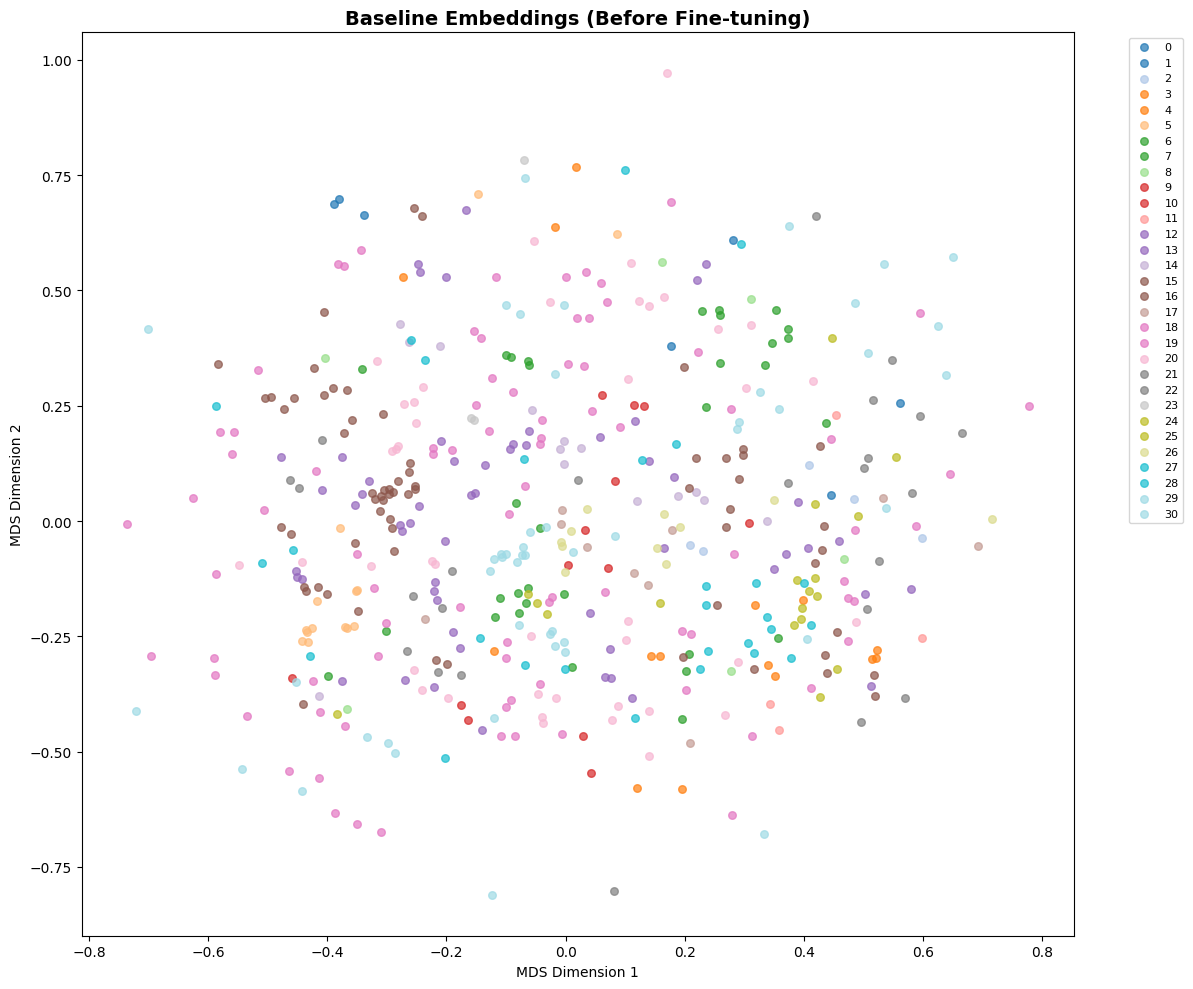

In [ ]:
# Visualize DINO embeddings
fig = visualize_embeddings_mds(
    baseline_embeddings,
    labels,
    "Baseline Embeddings (Before Fine-tuning)",
    seed=shared_config['seed']
)
plt.savefig(OUTPUT_PATH / "baseline_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"baseline_embeddings_mds": wandb.Image(fig)})

In [ ]:
baseline_emb_train_dataset = EmbeddingDataset(
    baseline_embeddings[train_mask],
    train_labels
)

baseline_emb_val_dataset = EmbeddingDataset(
    baseline_embeddings[~train_mask],
    val_labels
)

In [ ]:
def create_training_components(config, device):
    model = EmbeddingProjection(
        input_dim=dino_dim,
        output_dim=config["embedding_dim"],
        hidden_dim=config["hidden_dim"],
        dropout=config["dropout"]
    ).to(device)
    
    model.print_model_summary()
    
    wandb.log({"num_projection_params": sum(p.numel() for p in model.parameters())})
    
    criterion = CombinedLoss(
        first_loss=CenterLoss(
            num_classes=num_classes, 
            embedding_dim=config["embedding_dim"]
        ),
        second_loss=ProxyAnchorLoss(
            num_classes=num_classes, 
            embedding_dim=config["embedding_dim"], 
            margin=config["proxyanchor_margin"], 
            alpha=config["proxyanchor_alpha"]
        ),
        lambda_center=config["proxyanchor_lambda"]
    ).to(device)
    
    print(f"Combined Loss: CenterLoss + ProxyAnchor")
    print(f"  ProxyAnchor margin: {config['proxyanchor_margin']}")
    print(f"  ProxyAnchor alpha: {config['proxyanchor_alpha']}")
    print(f"  Lambda: {config['proxyanchor_lambda']}")
    
    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(criterion.parameters()),
        lr=config["init_learning_rate"],
        weight_decay=config["weight_decay"]
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=config["num_epochs"],
        eta_min=config["eta_min"]
    )
    
    print("Training components initialized:")
    print(f"  Optimizer: AdamW (lr={config['init_learning_rate']}, weight_decay={config['weight_decay']})")
    print(f"  Scheduler: CosineAnnealingLR (T_max={config['num_epochs']}, eta_min={config['eta_min']})")

    train_loader = create_deterministic_training_dataloader(
        baseline_emb_train_dataset,
        batch_size=config["batch_size"],
        seed=config['seed'],
        num_workers=num_workers,
        
    )
    val_loader = DataLoader(
        baseline_emb_val_dataset,
        batch_size=config["batch_size"],
        num_workers=num_workers,
        shuffle=False
    )

    return model, criterion, optimizer, scheduler, train_loader, val_loader

We consolidate all comparison plots and metrics into a single function for easier evaluation and analysis.


In [ ]:
random_idx = np.random.randint(0, len(val_labels))

def train(config, device, name):
    # Setup training components
    (
        model,
        criterion,
        optimizer,
        scheduler,
        train_loader,
        val_loader
    ) = create_training_components(config, device)
    
    # Training loop
    set_seeds(shared_config['seed'])
    checkpoint_path = CHECKPOINT_PATH / f"best_model_{name}.pth"
    start_time = time.time()
    history, best_map, best_epoch = train_loop(
        model, 
        train_loader, 
        val_loader, 
        criterion, 
        optimizer, 
        scheduler, 
        device,
        name=name,
        checkpoint_path=checkpoint_path,
        num_epochs=shared_config["num_epochs"],
        patience=shared_config["patience"],
        classes=label_encoder.classes_.tolist()
    )
    training_time = time.time() - start_time

    wandb.log({
        f"final_val_mAP_{name}": best_map,
        f"best_epoch_{name}": best_epoch,
        f"total_epochs_{name}": len(history['train_loss']),
        f"training_time_{name}": training_time
    })
    
    print(f"Training completed for {name}")
    print(f"  Best val mAP: {best_map:.4f} at epoch {best_epoch}")
    print(f"  Total training time: {training_time:.2f} seconds")
    
    
    # Plot training curves
    fig = plot_history(history, best_epoch)
    plt.savefig(CHECKPOINT_PATH / f'training_curves_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Log to W&B
    wandb.log({f"training_curves_{name}": wandb.Image(fig)})
    
    
    # Load best model
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    print(f"Loaded best model from epoch {best_epoch}")
    print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
    print(f"  Val mAP: {checkpoint['val_map']:.4f}")
    
    
    # Extract fine-tuned embeddings for training data
    model.eval()
    with torch.no_grad():
        train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
        finetuned_embeddings = model(train_tensor).cpu().numpy()
        finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

    print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
    print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")
    
    
    # Visualize fine-tuned embeddings
    fig_finetuned = visualize_embeddings_mds(
        finetuned_embeddings,
        labels,
        f"Fine-tuned Embeddings (After Training, {name})",
        seed=config['seed']
    )
    plt.savefig(OUTPUT_PATH / f"embeddings_mds_{name}.png")
    plt.show()

    # Log to W&B
    wandb.log({f"embeddings_mds_{name}": wandb.Image(fig_finetuned)})
    
    
    # Visualize nearest neighbors before and after fine-tuning
    fig, stats = visualize_nearest_neighbors(
        query_idx=random_idx,
        original_embeddings=baseline_embeddings[~train_mask],
        finetuned_embeddings=finetuned_embeddings[~train_mask],
        image_paths=image_paths[~train_mask],
        labels=val_labels,
        before_label='BEFORE\nFine-Tuning\n(DINOv3)',
        after_label='AFTER\nFine-Tuning\n(Center + Proxy Anchor)'
    )

    fig.savefig(OUTPUT_PATH / f"nearest_neighbors_{name}.png", dpi=150, bbox_inches='tight')
    fig.show()

    wandb.log({
        f"nearest_neighbors_{name}": wandb.Image(fig),
        f"nearest_neighbors_stats_{name}": stats,
    })
    
    return [
        name,
        best_map,
        best_epoch,
        training_time
    ]


In [ ]:
table = [
    ["Run ID", "Best val_mAP", "Best epoch", "Training time"]
]

## Baseline

For the baseline, we use the hyperparameters that were optimized in previous notebooks.


In [ ]:
# Baselin Configuration
baseline_config = {       
    # Model
    "embedding_dim": 256,
    "hidden_dim": 512,
    "dropout": 0.3,
    
    # ProxyAnchor
    "proxyanchor_margin": 0.1,
    "proxyanchor_alpha": 32.0,
    "proxyanchor_lambda": 0.0005,
    
    # Optimizer
    "init_learning_rate": 5e-3,
    "eta_min": 1e-5,
    "weight_decay": 1e-4,

    # Training
    "batch_size": 32,
    "weight_decay": 1e-4,
} | shared_config

print("Configuration:")
for key, value in baseline_config.items():
    print(f"  {key}: {value}")

In [ ]:
baseline_table_row = train(baseline_config, device, name="baseline")
table.append(baseline_table_row)

## Best Sweep Runs

In [ ]:
api = wandb.Api()
entity = api.viewer.entity  # gets your W&B username
sweep_path = f"{entity}/{os.getenv('WANDB_PROJECT')}/{shared_config['sweep_id']}"
print(f"Sweep results available at: https://wandb.ai/{sweep_path}")

In [ ]:
# Access the sweep via W&B API
api = wandb.Api()
sweep = api.sweep(sweep_path)

# Sort runs by your metric (final_val_mAP) descending
sorted_runs = sorted(
    sweep.runs, 
    key=lambda run: run.summary.get("final_val_mAP", float('-inf')),
    reverse=True
)

# Show the top runs
print(f"Top {shared_config['num_top_runs']} runs:")
for i, run in enumerate(sorted_runs[:shared_config["num_top_runs"]], 1):
    print(f"\nRank {i}:")
    print("Run ID:", run.id)
    print("final_val_mAP:", run.summary.get("final_val_mAP"))
    print("Hyperparameters:", run.config)

In [ ]:
candidate_runs = sorted_runs[:shared_config["num_top_runs"]]  # You can adjust this number based on how many top runs you want to analyze

In [ ]:
for run in candidate_runs:
    print(f"\nAnalyzing run {run.id}")
    row = train(run.config, device, name=run.id)
    table.append(row)

print("Finished analyzing top runs from the sweep")

## Summary

In [66]:
rows = list(zip(*table)) # transpose for tabulate
print(tabulate(rows[1:], headers=rows[0], tablefmt="grid"))

+------------+------------+------------+------------+----------------------+
| Strategy   |   Baseline |   Weighted |   Balanced |   Weighted Augmented |
+============+============+============+============+======================+
| val_mAP    |     0.8873 |     0.8823 |     0.9013 |                0.898 |
+------------+------------+------------+------------+----------------------+
| num_epochs |    30      |    41      |    34      |               51     |
+------------+------------+------------+------------+----------------------+


In [ ]:
# create df from table and log to W&B
df = pd.DataFrame(table[1:], columns=table[0])
print(df)

wandb.log({"experiment_summary": wandb.Table(dataframe=df)})

## Submission

In [ ]:
submission_model = "baseline"

submission_dict = {
    run.id: (CHECKPOINT_PATH / f"best_model_{run.id}.pth", run.config) for run in candidate_runs,
}
submission_dict["baseline"] = (CHECKPOINT_PATH / "best_model_baseline.pth", baseline_config)

if submission_model not in submission_dict:
    raise ValueError(f"Invalid submission model: {submission_model}")

checkpoint_path, config = submission_dict[submission_model]
config = config | shared_config

wandb.log({"submission_type": submission_model})

In [ ]:
model = EmbeddingProjection(
    input_dim=dino_dim,
    output_dim=config["embedding_dim"],
    hidden_dim=config["hidden_dim"],
    dropout=config["dropout"]
).to(device)

In [ ]:
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

FileNotFoundError: [Errno 2] No such file or directory: '/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/balancing/best_model.pth'

In [ ]:
# Load test.csv to get the pairs we need to score
test_pairs_df = pd.read_csv(DATA_PATH / "test.csv")

print(f"Test pairs to score: {len(test_pairs_df)}")
print(f"Columns: {list(test_pairs_df.columns)}")
print(f"\nSample rows:")
print(test_pairs_df.head())

Test pairs to score: 137270
Columns: ['row_id', 'query_image', 'gallery_image']

Sample rows:
   row_id    query_image  gallery_image
0       0  test_0001.png  test_0002.png
1       1  test_0001.png  test_0003.png
2       2  test_0001.png  test_0004.png
3       3  test_0001.png  test_0005.png
4       4  test_0001.png  test_0006.png


In [ ]:
# Get unique test images
test_images = set(test_pairs_df['query_image'].unique()) | set(test_pairs_df['gallery_image'].unique())
test_images = sorted(list(test_images))

print(f"Unique test images: {len(test_images)}")

# Build paths
test_image_paths = [DATA_PATH / "test" / filename for filename in test_images]

test_loader = DataLoader(
    BlurImageDataset(
        test_image_paths,
        preprocess_fn=dino_preprocess
    ),
    batch_size=32,
    num_workers=num_workers,
    shuffle=False
)

# Extract embeddings for test images
print(f"\nExtracting embeddings for test images...")
test_embeddings = extract_embeddings(
    model=dino,
    data_loader=test_loader,
    device=device,
    desc="Test embeddings"
)

print(f"Test embeddings shape: {test_embeddings.shape}")

Unique test images: 371

Extracting embeddings for test images...


Test embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Test embeddings: 100%|██████████| 12/12 [00:59<00:00,  4.96s/it]

Test embeddings shape: (371, 768)


In [ ]:
# Project through fine-tuned model
model.eval()
with torch.no_grad():
    test_tensor = torch.FloatTensor(test_embeddings).to(device)
    test_finetuned_embeddings = model(test_tensor).cpu().numpy()
    test_finetuned_embeddings = test_finetuned_embeddings / np.linalg.norm(test_finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned test embeddings shape: {test_finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(test_finetuned_embeddings, axis=1).mean():.4f}")

# Create mapping from filename to embedding
img_to_embedding = {
    filename: embedding 
    for filename, embedding in zip(test_images, test_finetuned_embeddings)
}

Fine-tuned test embeddings shape: (371, 256)
Mean L2 norm: 1.0000


In [ ]:
# Compute similarity for each pair
print("Computing pairwise similarities...")
similarities = []

for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df), desc="Computing similarities"):
    query_emb = img_to_embedding[row['query_image']]
    gallery_emb = img_to_embedding[row['gallery_image']]
    
    # Cosine similarity (embeddings are already normalized)
    sim = np.dot(query_emb, gallery_emb)
    similarities.append(sim)

# Clip to [0, 1] range
similarities = np.array(similarities)
similarities = np.clip(similarities, 0.0, 1.0)

print(f"\nSimilarity statistics:")
print(f"  Min: {similarities.min():.4f}")
print(f"  Max: {similarities.max():.4f}")
print(f"  Mean: {similarities.mean():.4f}")
print(f"  Std: {similarities.std():.4f}")

Computing pairwise similarities...
Similarity matrix shape: (371, 371) Sim range: [0.0016, 1.0000]


Computing similarities: 100%|██████████| 137270/137270 [00:03<00:00, 38067.04it/s]


Similarity statistics:
  Min: 0.0016
  Max: 1.0000
  Mean: 0.8596
  Std: 0.1542


In [ ]:
# Create submission DataFrame
submission_df = pd.DataFrame({
    'row_id': test_pairs_df['row_id'],
    'similarity': similarities
})

print("Submission DataFrame:")
print(submission_df.head(10))

# Verify format matches sample submission
sample_submission = pd.read_csv(DATA_PATH / "sample_submission.csv")
print(f"\nFormat check:")
print(f"  Expected columns: {list(sample_submission.columns)}")
print(f"  Our columns: {list(submission_df.columns)}")
print(f"  Expected rows: {len(sample_submission)}")
print(f"  Our rows: {len(submission_df)}")

Submission DataFrame:
   row_id  similarity
0       0    0.643482
1       1    0.882659
2       2    0.765042
3       3    0.810544
4       4    0.809093
5       5    0.638782
6       6    0.866316
7       7    0.840366
8       8    0.767672
9       9    0.810581

Format check:
  Expected columns: ['row_id', 'similarity']
  Our columns: ['row_id', 'similarity']
  Expected rows: 137270
  Our rows: 137270


In [ ]:
# Save submission
submission_path = OUTPUT_PATH / "submission.csv"
submission_df.to_csv(submission_path, index=False)

print(f"Submission saved to: {submission_path}")
print(f"File size: {submission_path.stat().st_size / 1024:.1f} KB")

Submission saved to: /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/reranking/submission.csv
File size: 2217.3 KB


## Artifacts

In [ ]:
# Save model as W&B artifact
for key in submission_dict:
    checkpoint_path, _ = submission_dict[key]
    model_artifact = wandb.Artifact(
        name=f"model-{key}",
        type="model",
        description="Center + ProxyAnchor fine-tuned MegaDescriptor model for jaguar re-identification with config from run: " + key
    )
    model_artifact.add_file(checkpoint_path)
    wandb.log_artifact(model_artifact)

print("Model artifacts saved to W&B")

Model artifacts saved to W&B


In [ ]:
# Save submission as W&B artifact
submission_artifact = wandb.Artifact(
    name="submission",
    type="submission",
    description=f"Competition submission file for {submission_model} loss"
)
submission_artifact.add_file(str(submission_path))
wandb.log_artifact(submission_artifact)

print("Submission artifact saved to W&B")

Submission artifact saved to W&B


In [ ]:
wandb.finish()

best_epoch_baseline,▁
best_epoch_bg_image,▁
best_epoch_blur_bg,▁
best_epoch_const_bg,▁
best_epoch_extend_fg,▁
best_epoch_noise_bg,▁
best_epoch_sample_fg,▁
epoch,▃▄▅▅▇▁▂▂▄▄▅▆▇▇█▂▂▃▃▄▅▅▇█▁▂▃▃▇▇▁▃▆▇▁▆▇▄▄▆
final_val_mAP_baseline,▁
final_val_mAP_bg_image,▁
+21,...
